## 1. Project Introduction

### 1.1 Problem Statement

Bike-sharing systems generate large amounts of usage data containing information
about time, weather, seasonality, and working-day conditions.

The goal of this project is to develop regression models that can predict the
total number of bike rentals in a given hour.

### 1.2 Machine Learning Problem

This is a **supervised regression problem** because:

- The input variables describe the conditions for a particular hour.
- The target variable `cnt` represents the total number of bike rentals.
- The target is a continuous numerical value.

### 1.3 Target Variable

The target variable is:

`cnt` — Total number of bike rentals.

### 1.4 Project Goal

The main goal is to compare multiple regression algorithms and identify a model
that provides strong predictive performance while maintaining reliable
generalisation on unseen test data.

## 2. Import Libraries

The libraries required for data manipulation, visualization, preprocessing,
model training, evaluation, hyperparameter tuning, and dimensionality reduction
are imported below.

In [2]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.decomposition import PCA

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 3. Loading the Dataset

The hourly Bike Sharing dataset is loaded into a Pandas DataFrame.

The dataset contains information about weather, season, calendar information, time of day, and bike rental counts.

In [4]:
# Load the hourly Bike Sharing dataset
df = pd.read_csv("../Data/hour.csv")

# Display the first five rows
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 4. Initial Data Understanding

Before preprocessing the dataset, we inspect its structure.

The following aspects are examined:

- Number of rows and columns
- Column names
- Data types
- Basic statistical information
- Target variable distribution

In [6]:
# Dataset dimensions
print("Dataset shape:", df.shape)
# Display column names
print("Columns:")
print(df.columns.tolist())

Dataset shape: (17379, 17)
Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [7]:
# Display data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


In [9]:
# Target variable overview
print("Target variable: cnt")
print("Minimum:", df["cnt"].min())
print("Maximum:", df["cnt"].max())
print("Mean:", df["cnt"].mean())
print("Median:", df["cnt"].median())

Target variable: cnt
Minimum: 1
Maximum: 977
Mean: 189.46308763450142
Median: 142.0


## 5. Data Quality Analysis

Data quality is checked before model development.

We examine:

- Missing values
- Duplicate rows
- Potentially invalid values
- Data types
- Duplicate treatment

These checks help ensure that the dataset is suitable for subsequent analysis and modelling.

In [10]:
# Check missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# Check unique values for categorical/time-related columns
categorical_check_columns = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_check_columns:
    print(f"{col}: {sorted(df[col].unique())}")

season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr: [np.int64(0), np.int64(1)]
mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
hr: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
holiday: [np.int64(0), np.int64(1)]
weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
workingday: [np.int64(0), np.int64(1)]
weathersit: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics of the dataset before model training.

The analysis focuses on:

- Feature distributions
- Target distribution
- Relationships between numerical features
- Correlations
- Feature-target relationships
- Patterns associated with time and weather

## 6.1 Numerical Feature Distributions

Distribution plots are used to understand the range, spread, skewness, and potential extreme values of numerical variables.

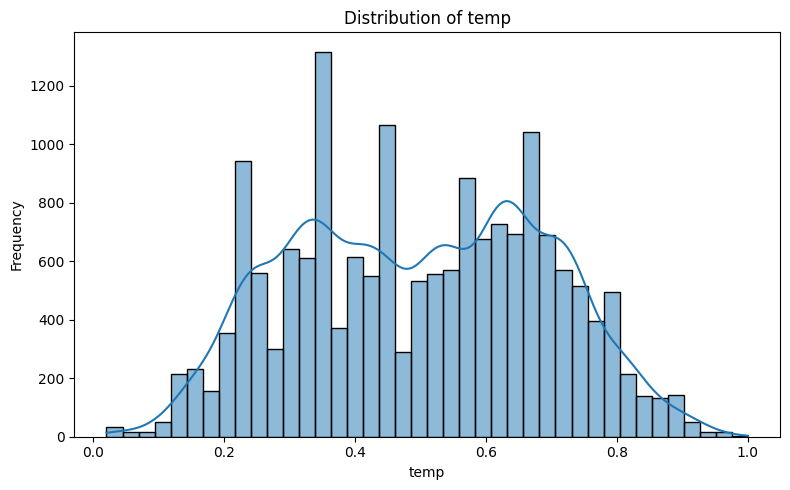

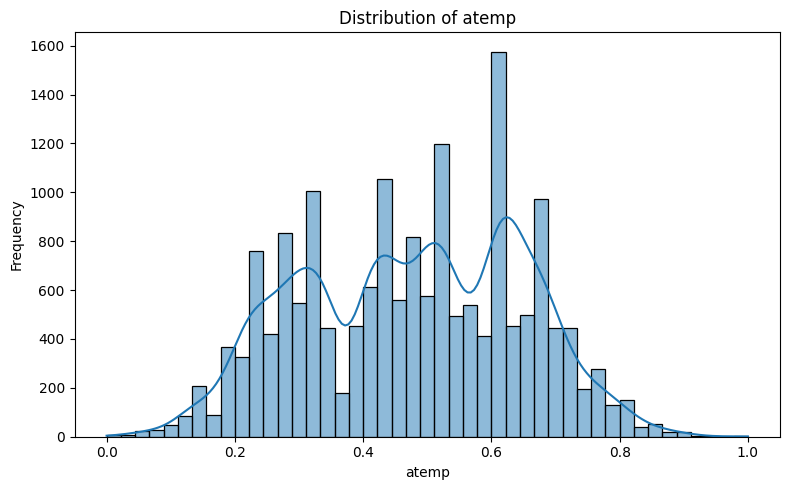

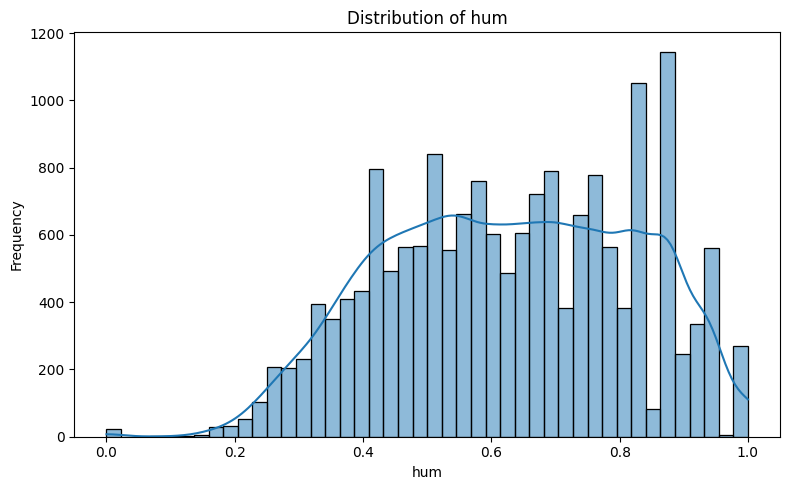

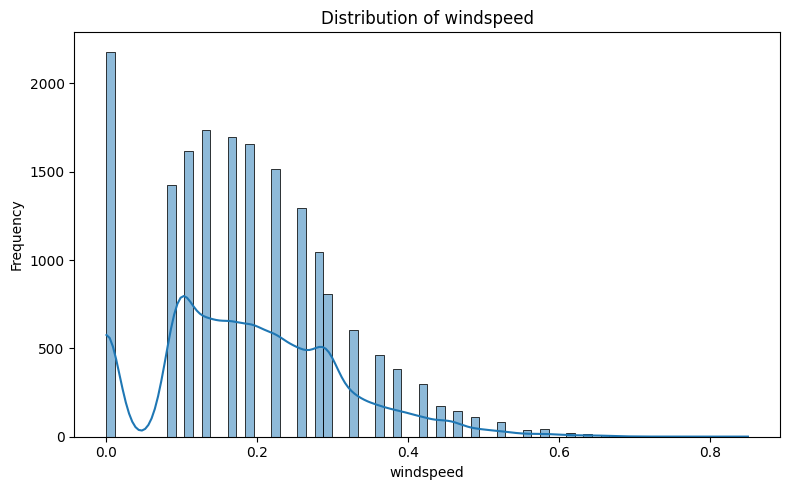

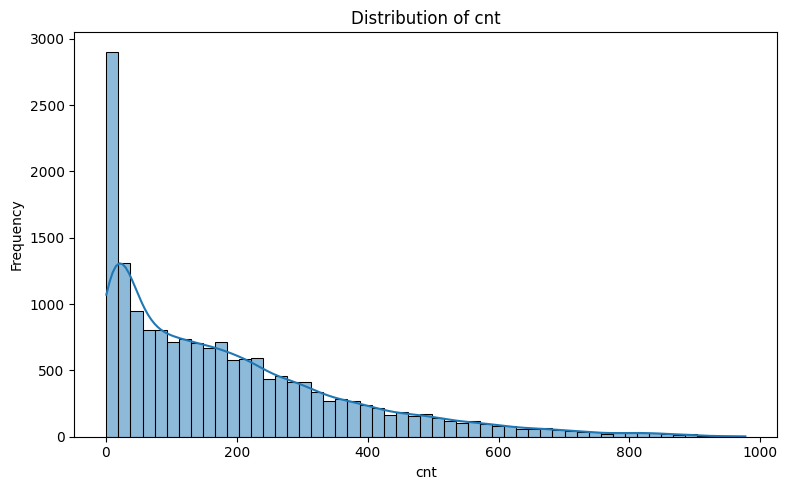

In [13]:
# Numerical columns for EDA
numerical_eda = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt"
]

# Plot distributions
for col in numerical_eda:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 6.2 Categorical and Temporal Feature Distributions

Bar plots are used to understand how observations are distributed across seasons, months, hours, weekdays, working days, and weather conditions.

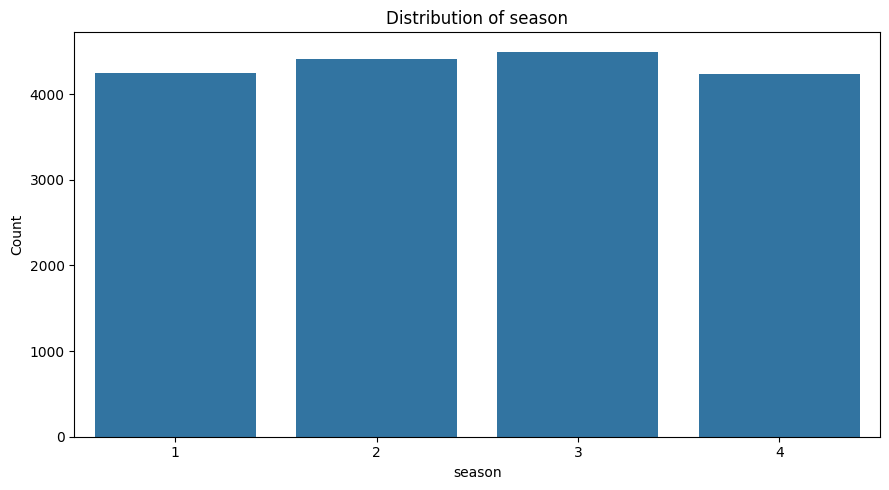

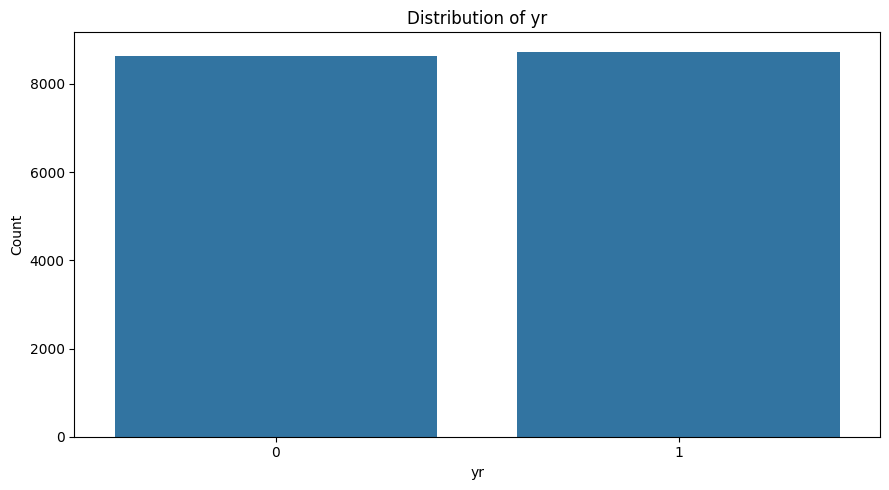

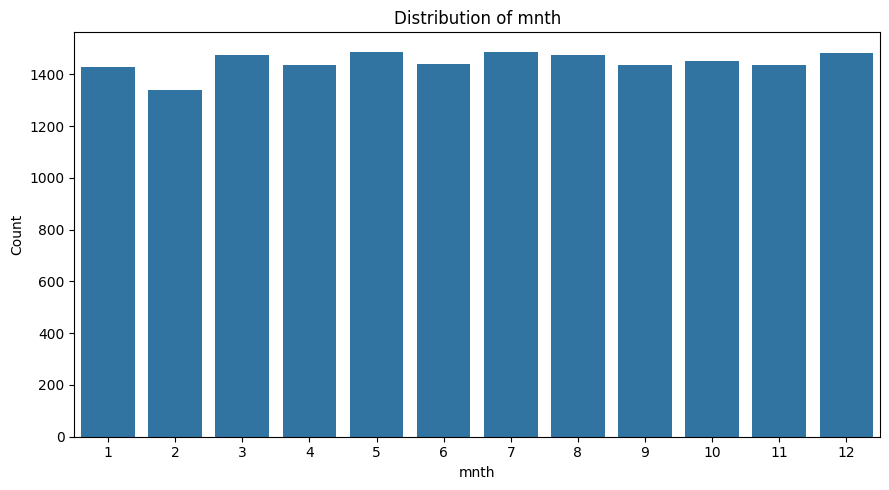

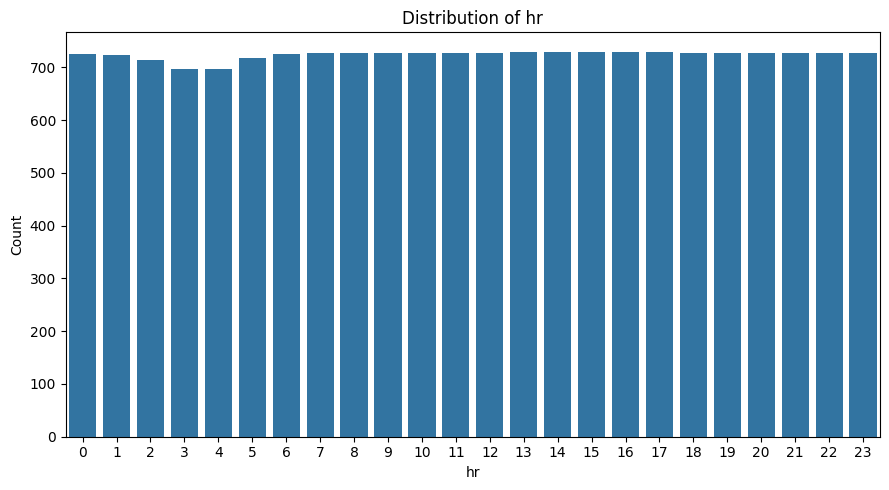

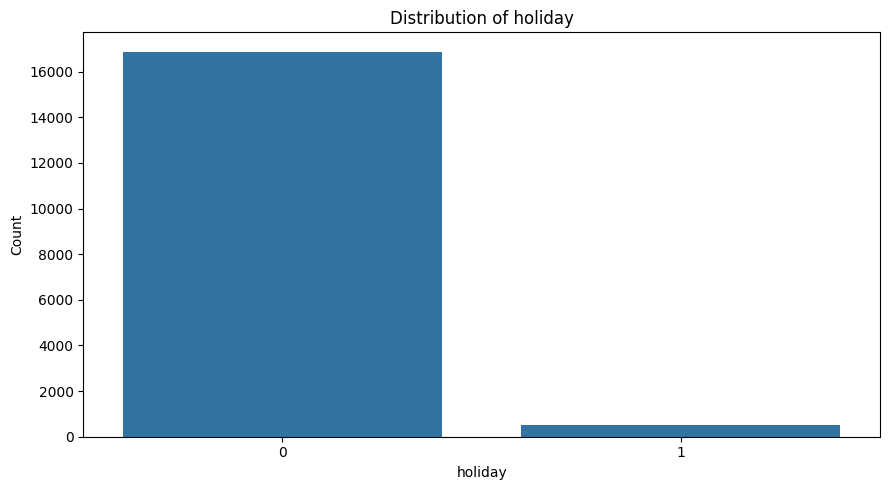

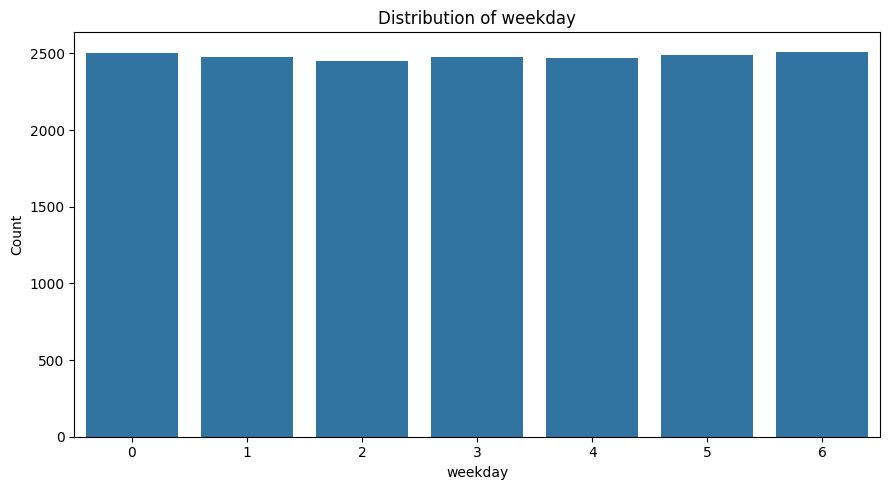

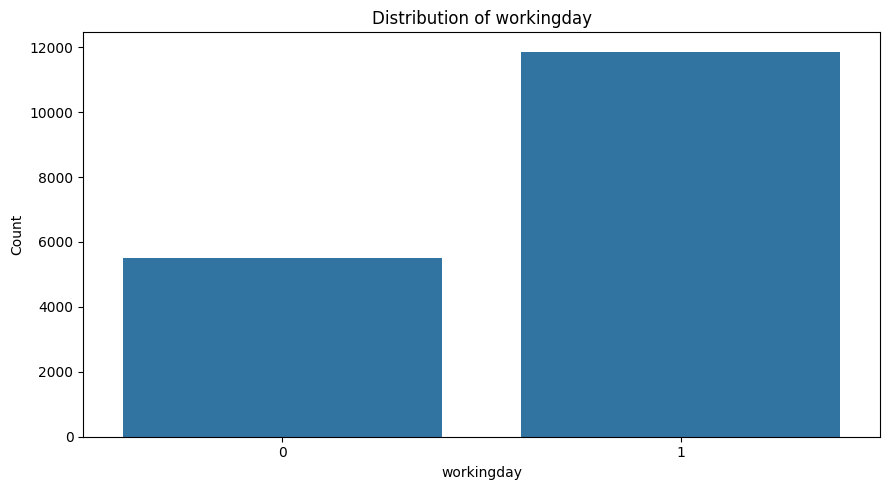

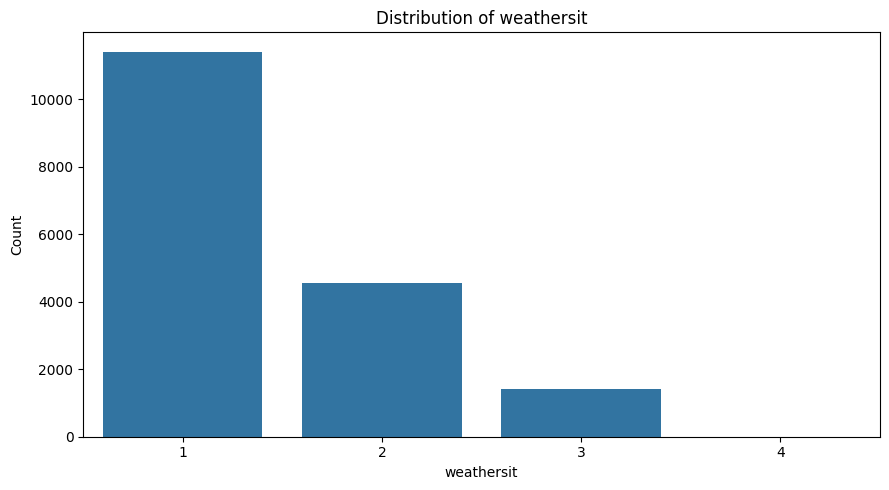

In [14]:
categorical_eda = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_eda:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 6.4 Correlation Analysis

A correlation heatmap is used to examine linear relationships between numerical variables and the target variable.

Correlation values range from -1 to +1:

- Values close to +1 indicate a strong positive linear relationship.
- Values close to -1 indicate a strong negative linear relationship.
- Values close to 0 indicate a weak linear relationship.

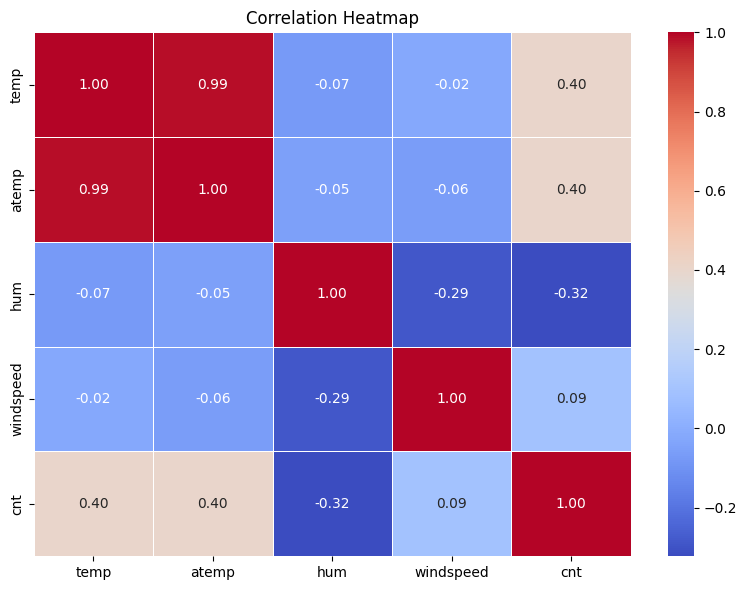

In [15]:
# Select numerical columns for correlation analysis
correlation_columns = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt"
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6.5 Feature-Target Relationship: Temperature vs Demand

A scatter plot is used to visually examine the relationship between temperature and total bike rental demand.

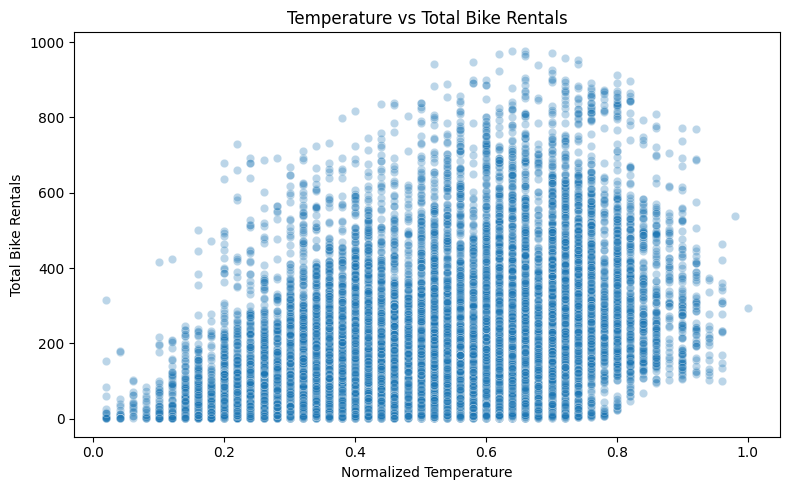

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temp",
    y="cnt",
    alpha=0.3
)

plt.title("Temperature vs Total Bike Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Bike Rentals")

plt.tight_layout()
plt.show()

## 6.6 Feature-Target Relationship: Humidity vs Demand

A second scatter plot is used to examine the relationship between humidity and total bike rental demand.

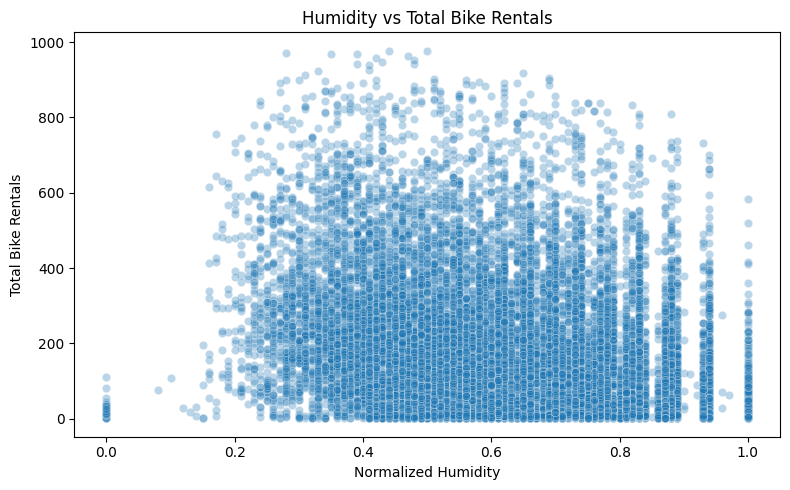

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="hum",
    y="cnt",
    alpha=0.3
)

plt.title("Humidity vs Total Bike Rentals")
plt.xlabel("Normalized Humidity")
plt.ylabel("Total Bike Rentals")

plt.tight_layout()
plt.show()

# 7. Outlier Analysis

Outliers are examined to determine whether extreme observations are errors or legitimate observations.

In a bike-sharing dataset, unusually high rental counts may represent genuine periods of high demand. Therefore, extreme values should not automatically be removed.

The analysis distinguishes between:

- Invalid/impossible observations
- Legitimate extreme observations

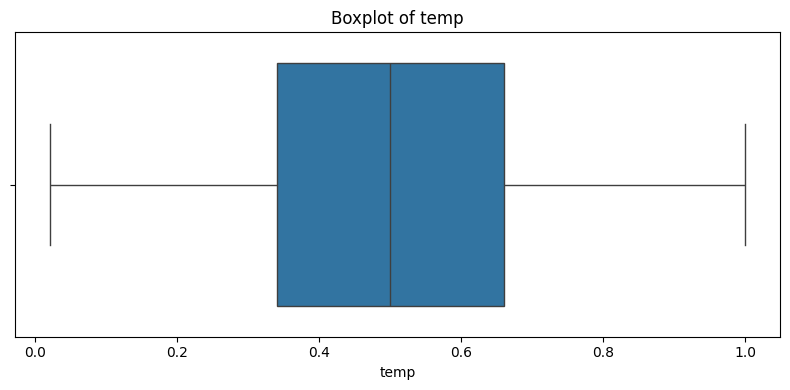

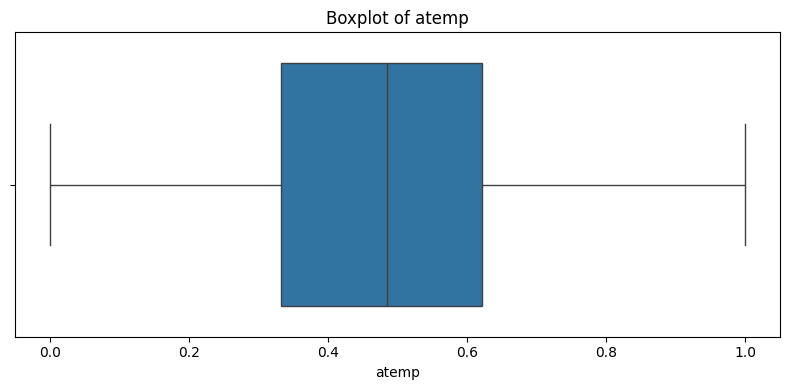

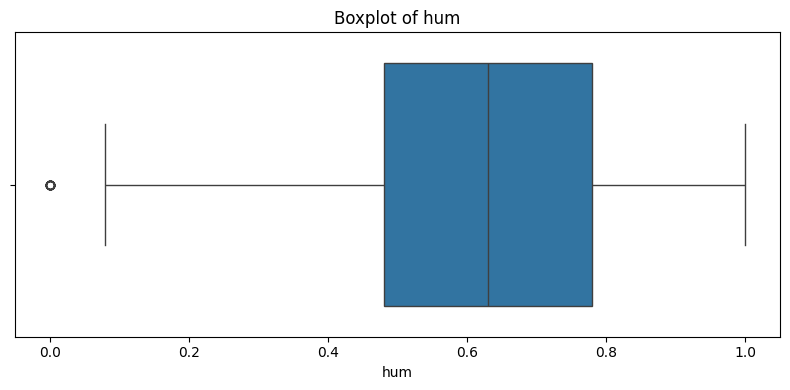

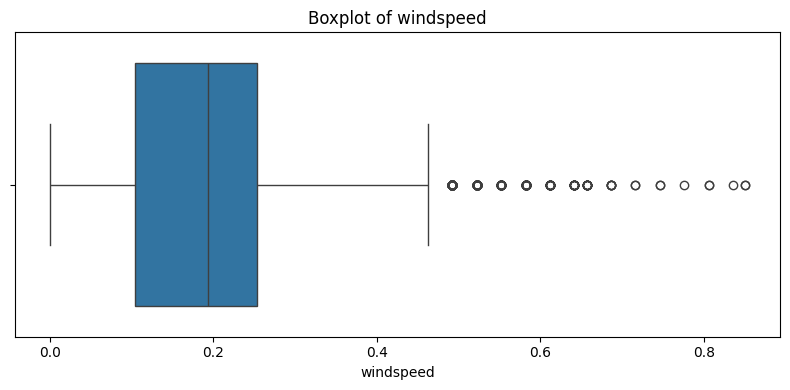

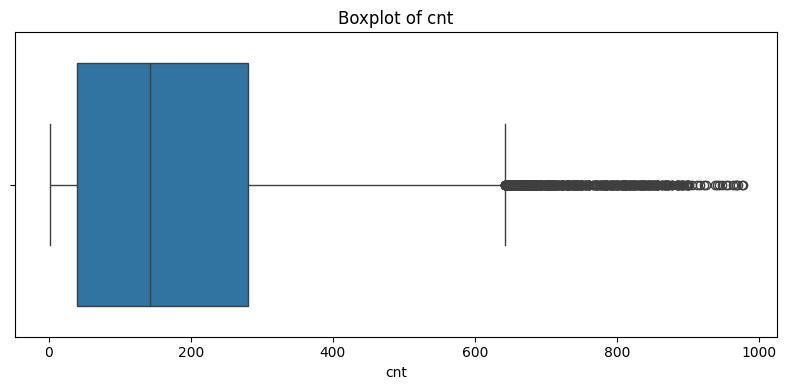

In [18]:
# Boxplots for numerical variables
for col in numerical_eda:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

# 8. Feature Engineering

Feature engineering creates additional information that may help regression models capture patterns in the data.

The `dteday` column contains date information. It will first be converted into a datetime representation, and the day of the month will be extracted as an additional feature.

The dataset already contains year, month, weekday, and hour information, so these existing variables will not be redundantly recreated.
\

In [5]:
# Convert date column to datetime
df["dteday"] = pd.to_datetime(df["dteday"])

# Extract day of month as an additional feature
df["day"] = df["dteday"].dt.day

# Display the new feature
df[["dteday", "day"]].head()

,dteday,day
0,2011-01-01,1
1,2011-01-01,1
2,2011-01-01,1
3,2011-01-01,1
4,2011-01-01,1


### Why was `day` engineered?

The day of the month may capture short-term variation within each month that is not directly represented by the existing month variable.

This feature is therefore included as an additional temporal predictor and its usefulness will be evaluated through model performance.

# 9. Target Leakage Prevention

Target leakage occurs when information that would not realistically be available at prediction time is used as an input feature.

The target variable is:

`cnt` = total number of bike rentals.

The variables `casual` and `registered` are components of `cnt`:

`cnt = casual + registered`

Therefore, including either of these variables would cause target leakage.

The `instant` column is also excluded because it acts as a record/index identifier rather than a meaningful predictive feature.

The original `dteday` column will also be removed after extracting the engineered `day` feature.

In [6]:
# Define target
TARGET = "cnt"

# Columns excluded from modelling
columns_to_drop = [
    "instant",
    "dteday",
    "casual",
    "registered"
]

# Create modelling dataset
model_df = df.drop(columns=columns_to_drop)

print("Remaining columns:")
print(model_df.columns.tolist())

Remaining columns:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'day']


# 10. Defining Features and Target

The dataset is separated into:

- `X`: predictor variables
- `y`: target variable

The target variable `cnt` represents total bike rental demand.

In [7]:
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (17379, 13)
Target shape: (17379,)


# 11. Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split.

The same split will be used for all ten regression algorithms to ensure that their performance comparisons are fair.

`random_state=42` is used to make the experiment reproducible. 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (13903, 13)
Testing set : (3476, 13)


In [9]:
# Numerical features selected for outlier treatment
outlier_features = ["temp", "atemp", "hum", "windspeed"]

# Calculate IQR bounds using TRAINING DATA ONLY
Q1 = X_train[outlier_features].quantile(0.25)
Q3 = X_train[outlier_features].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Display the calculated bounds
outlier_bounds = pd.DataFrame({
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound
})

outlier_bounds

,Lower Bound,Upper Bound
temp,-0.14000,1.14000
atemp,-0.09855,1.05305
hum,0.00500,1.24500
windspeed,-0.11930,0.47750


In [10]:
# Apply capping using the training-derived bounds
X_train[outlier_features] = X_train[outlier_features].clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

X_test[outlier_features] = X_test[outlier_features].clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

print("Outlier capping completed.")

Outlier capping completed.


### Outlier Treatment

Potential outliers were first identified using the IQR method. Since extreme
values in weather-related variables may represent genuine observations,
these observations were retained rather than removed.

IQR-based capping was applied to the selected continuous predictor variables
(`temp`, `atemp`, `hum`, and `windspeed`). The lower and upper bounds were
calculated using the training data only and then applied to both the training
and testing sets. This reduces the influence of extreme predictor values
while preserving the observations.

The target variable `cnt` was not capped because high rental counts may
represent genuine demand.

# 12. Data Preprocessing

Different types of features require different preprocessing strategies.

### Numerical Features

Numerical features will use:

1. Median imputation
2. StandardScaler

### Categorical / Discrete Features

The following variables represent categorical or discrete states:

- season
- yr
- mnth
- hr
- holiday
- weekday
- workingday
- weathersit

They will use:

1. Most-frequent imputation
2. One-hot encoding

The preprocessing is implemented using a `ColumnTransformer` so that transformations are applied consistently within the modelling pipeline.

In [11]:
# Define categorical and numerical columns
categorical_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

numerical_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "day"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

Numerical features:
['temp', 'atemp', 'hum', 'windspeed', 'day']


In [12]:
# Numerical preprocessing pipeline
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-fitted preprocessing to test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (13903, 62)
Processed testing shape : (3476, 62)


### Preprocessing Verification

The preprocessing object is fitted only using the training data.

The same fitted transformations are then applied to the test data.

This prevents information from the test set from influencing the preprocessing stage and avoids data leakage.

## 12. Regression Model Training

In this section, ten regression algorithms are trained using the same
preprocessed training dataset. Each model is evaluated on the same held-out
test dataset to ensure a fair comparison.

The following algorithms are implemented:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor (KNN)

### Model Evaluation Function

To maintain consistency, a common evaluation function is used for all
regression models. The evaluation metrics are R², RMSE, and MAE.

In [15]:
# Function to train and evaluate a regression model
def evaluate_regression_model(model, X_train, X_test, y_train, y_test):
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Generate predictions on the test set
    predictions = model.predict(X_test)
    
    # Calculate evaluation metrics
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    
    return model, predictions, r2, rmse, mae

### 12.1 Linear Regression

Linear Regression is used as the baseline regression model. It assumes a
linear relationship between the input features and the target variable.

In [16]:
linear_model = LinearRegression()

linear_model, linear_predictions, linear_r2, linear_rmse, linear_mae = (
    evaluate_regression_model(
        linear_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Linear Regression")
print("R²  :", linear_r2)
print("RMSE:", linear_rmse)
print("MAE :", linear_mae)

Linear Regression
R²  : 0.6814213839692052
RMSE: 100.43865251791378
MAE : 74.09963898865215


### 12.2 Ridge Regression

Ridge Regression applies L2 regularisation to reduce the effect of
multicollinearity and overly large model coefficients.

In [17]:
ridge_model = Ridge(alpha=1.0)

ridge_model, ridge_predictions, ridge_r2, ridge_rmse, ridge_mae = (
    evaluate_regression_model(
        ridge_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Ridge Regression")
print("R²  :", ridge_r2)
print("RMSE:", ridge_rmse)
print("MAE :", ridge_mae)

Ridge Regression
R²  : 0.6815549764310562
RMSE: 100.41759138397148
MAE : 74.08711149389251


### 12.3 Lasso Regression

Lasso Regression uses L1 regularisation. It can reduce some feature
coefficients to zero, which can provide a form of feature selection.

In [18]:
lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso_model, lasso_predictions, lasso_r2, lasso_rmse, lasso_mae = (
    evaluate_regression_model(
        lasso_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Lasso Regression")
print("R²  :", lasso_r2)
print("RMSE:", lasso_rmse)
print("MAE :", lasso_mae)

Lasso Regression
R²  : 0.681454010398582
RMSE: 100.43350929997202
MAE : 74.09529338149987


### 12.4 ElasticNet Regression

ElasticNet combines L1 and L2 regularisation. It can provide both
coefficient shrinkage and feature selection.

In [19]:
elastic_model = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model, elastic_predictions, elastic_r2, elastic_rmse, elastic_mae = (
    evaluate_regression_model(
        elastic_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("ElasticNet Regression")
print("R²  :", elastic_r2)
print("RMSE:", elastic_rmse)
print("MAE :", elastic_mae)

ElasticNet Regression
R²  : 0.6818458618558263
RMSE: 100.37171739454863
MAE : 74.05666177439099


### 12.5 Polynomial Regression

Polynomial Regression extends Linear Regression by creating polynomial
combinations of numerical features. A degree-2 polynomial transformation is
used to capture possible nonlinear relationships while keeping the feature
space manageable.

Categorical features are encoded separately and are not subjected to
polynomial expansion.

In [20]:
# Preprocessing pipeline specifically for Polynomial Regression

polynomial_numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("polynomial", PolynomialFeatures(
            degree=2,
            include_bias=False
        ))
    ]
)

polynomial_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

polynomial_preprocessor = ColumnTransformer(
    transformers=[
        ("num", polynomial_numerical_transformer, numerical_features),
        ("cat", polynomial_categorical_transformer, categorical_features)
    ]
)

# Transform the training and test data
X_train_poly = polynomial_preprocessor.fit_transform(X_train)
X_test_poly = polynomial_preprocessor.transform(X_test)

print("Original preprocessed features:", X_train_processed.shape[1])
print("Polynomial features:", X_train_poly.shape[1])

Original preprocessed features: 62
Polynomial features: 77


In [21]:
polynomial_model = LinearRegression()

polynomial_model, polynomial_predictions, polynomial_r2, polynomial_rmse, polynomial_mae = (
    evaluate_regression_model(
        polynomial_model,
        X_train_poly,
        X_test_poly,
        y_train,
        y_test
    )
)

print("Polynomial Regression")
print("R²  :", polynomial_r2)
print("RMSE:", polynomial_rmse)
print("MAE :", polynomial_mae)

Polynomial Regression
R²  : 0.6873057466330709
RMSE: 99.50674427097908
MAE : 73.21147195967937


### 12.11 Regression Model Comparison

The performance of all ten regression algorithms is consolidated into a
single comparison table. The models are ranked according to their R² score.

In [22]:
# Store results from all ten regression models

results = [
    ["Linear Regression", linear_r2, linear_rmse, linear_mae],
    ["Ridge Regression", ridge_r2, ridge_rmse, ridge_mae],
    ["Lasso Regression", lasso_r2, lasso_rmse, lasso_mae],
    ["ElasticNet Regression", elastic_r2, elastic_rmse, elastic_mae],
    ["Polynomial Regression", polynomial_r2, polynomial_rmse, polynomial_mae],
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "R²", "RMSE", "MAE"]
)

# Rank models by R²
results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

# Display the comparison table
results_df

,Model,R²,RMSE,MAE
0,Polynomial Regression,0.687306,99.506744,73.211472
1,ElasticNet Regression,0.681846,100.371717,74.056662
2,Ridge Regression,0.681555,100.417591,74.087111
3,Lasso Regression,0.681454,100.433509,74.095293
4,Linear Regression,0.681421,100.438653,74.099639


## 13. Hyperparameter Tuning

The baseline models were trained using their initial parameter settings.
In this section, hyperparameter tuning is performed on Random Forest and
Gradient Boosting using GridSearchCV.

GridSearchCV evaluates different combinations of hyperparameters using
cross-validation on the training data and selects the combination that
provides the best R² score.

The test set remains untouched during tuning and is used only for the final
evaluation of the tuned models.

### 13.1 Ridge Regression Hyperparameter Tuning

In [23]:
# Ridge Regression hyperparameter tuning

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best CV R²:", ridge_grid.best_score_)

Best Ridge Parameters: {'model__alpha': 1}
Best CV R²: 0.6842510575711214


### 13.2 Lasso Regression Hyperparameter Tuning

In [24]:
# Lasso Regression hyperparameter tuning

lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=10000))
    ]
)

lasso_param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Parameters:", lasso_grid.best_params_)
print("Best CV R²:", lasso_grid.best_score_)

Best Lasso Parameters: {'model__alpha': 0.01}
Best CV R²: 0.6842498728336285


### 13.3 ElasticNet Regression Hyper Tuning

In [26]:
# ElasticNet hyperparameter tuning

elastic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ElasticNet(max_iter=10000))
    ]
)

elastic_param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    elastic_pipeline,
    elastic_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(X_train, y_train)

print("Best ElasticNet Parameters:", elastic_grid.best_params_)
print("Best CV R²:", elastic_grid.best_score_)

Best ElasticNet Parameters: {'model__alpha': 0.0001, 'model__l1_ratio': 0.1}
Best CV R²: 0.6842510465542372


### 13.4 Polynomial Regression Hyper Tuning

In [27]:
# Polynomial Regression degree tuning

polynomial_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("poly", PolynomialFeatures(
                        degree=2,
                        include_bias=False
                    ))
                ]
            ),
            numerical_features
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    ))
                ]
            ),
            categorical_features
        )
    ]
)

polynomial_pipeline = Pipeline(
    steps=[
        ("preprocessor", polynomial_preprocessor),
        ("model", LinearRegression())
    ]
)

polynomial_param_grid = {
    "preprocessor__num__poly__degree": [2, 3]
}

polynomial_grid = GridSearchCV(
    polynomial_pipeline,
    polynomial_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

polynomial_grid.fit(X_train, y_train)

print("Best Polynomial Parameters:", polynomial_grid.best_params_)
print("Best CV R²:", polynomial_grid.best_score_)

Best Polynomial Parameters: {'preprocessor__num__poly__degree': 3}
Best CV R²: 0.7026043184821013


## 14. Tuned Model Evaluation

The tuned models are evaluated on the same held-out test set used for
the baseline models. This allows a fair comparison between the baseline
and tuned versions of each regression algorithm.

The evaluation metrics used are R², RMSE, and MAE.

In [28]:
# Store tuned models and their predictions

tuned_models = {
    "Ridge Regression": ridge_grid,
    "Lasso Regression": lasso_grid,
    "ElasticNet Regression": elastic_grid,
    "Polynomial Regression": polynomial_grid,
}

tuned_results = []

for name, model in tuned_models.items():

    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    tuned_results.append([
        name,
        r2,
        rmse,
        mae
    ])

tuned_results_df = pd.DataFrame(
    tuned_results,
    columns=["Model", "R²", "RMSE", "MAE"]
)

tuned_results_df = tuned_results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

tuned_results_df

,Model,R²,RMSE,MAE
0,Polynomial Regression,0.699208,97.594558,72.414281
1,Lasso Regression,0.681688,100.396574,74.058735
2,ElasticNet Regression,0.681579,100.413764,74.084703
3,Ridge Regression,0.681555,100.417591,74.087111


In [29]:
# Create baseline results table with consistent model names

baseline_results_df = results_df.copy()

baseline_results_df = baseline_results_df.rename(
    columns={
        "R²": "Baseline R²",
        "RMSE": "Baseline RMSE",
        "MAE": "Baseline MAE"
    }
)

tuned_comparison_df = tuned_results_df.rename(
    columns={
        "R²": "Tuned R²",
        "RMSE": "Tuned RMSE",
        "MAE": "Tuned MAE"
    }
)

baseline_vs_tuned = baseline_results_df.merge(
    tuned_comparison_df,
    on="Model",
    how="left"
)

baseline_vs_tuned["R² Improvement"] = (
    baseline_vs_tuned["Tuned R²"]
    - baseline_vs_tuned["Baseline R²"]
)

baseline_vs_tuned["RMSE Improvement"] = (
    baseline_vs_tuned["Baseline RMSE"]
    - baseline_vs_tuned["Tuned RMSE"]
)

baseline_vs_tuned["MAE Improvement"] = (
    baseline_vs_tuned["Baseline MAE"]
    - baseline_vs_tuned["Tuned MAE"]
)

baseline_vs_tuned.sort_values(
    by="Tuned R²",
    ascending=False
).reset_index(drop=True)

,Model,Baseline R²,Baseline RMSE,Baseline MAE,Tuned R²,Tuned RMSE,Tuned MAE,R² Improvement,RMSE Improvement,MAE Improvement
0,Polynomial Regression,0.687306,99.506744,73.211472,0.699208,97.594558,72.414281,0.011902,1.912186,0.797191
1,Lasso Regression,0.681454,100.433509,74.095293,0.681688,100.396574,74.058735,0.000234,0.036936,0.036558
2,ElasticNet Regression,0.681846,100.371717,74.056662,0.681579,100.413764,74.084703,-0.000267,-0.042047,-0.028041
3,Ridge Regression,0.681555,100.417591,74.087111,0.681555,100.417591,74.087111,0.000000,0.000000,0.000000
4,Linear Regression,0.681421,100.438653,74.099639,NaN,NaN,NaN,NaN,NaN,NaN


## 15. 5-Fold Cross-Validation

Five-fold cross-validation is performed on the training data for all
regression models. The training data is divided into five folds, with
each fold being used once as the validation set while the remaining
four folds are used for training.

The mean and standard deviation of the R² scores are reported to
compare the consistency of model performance across different folds.

The held-out test set is not used during cross-validation.

In [30]:
from sklearn.model_selection import KFold, cross_val_score

# Five-fold cross-validation setup

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-Fold Cross-Validation configured successfully.")

5-Fold Cross-Validation configured successfully.


In [31]:
# Add Linear Regression because it does not have hyperparameters to tune

all_models_for_cv = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_grid,
    "Lasso Regression": lasso_grid,
    "ElasticNet Regression": elastic_grid,
    "Polynomial Regression": polynomial_grid,
}

In [32]:
# Perform 5-fold cross-validation for all models

cv_results = []

for model_name, model in all_models_for_cv.items():

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append([
        model_name,
        cv_scores.mean(),
        cv_scores.std()
    ])

    print(f"{model_name}")
    print("Fold R² scores:", cv_scores)
    print("Mean R²:", cv_scores.mean())
    print("Standard Deviation:", cv_scores.std())
    print("-" * 50)

Linear Regression
Fold R² scores: [0.39250442 0.39744314 0.39997725 0.37369648 0.37162633]
Mean R²: 0.3870495249858902
Standard Deviation: 0.01200906179337553
--------------------------------------------------
Ridge Regression
Fold R² scores: [0.70268815 0.66269024 0.69566778 0.68186421 0.67365083]
Mean R²: 0.6833122418149721
Standard Deviation: 0.01448303611257259
--------------------------------------------------
Lasso Regression
Fold R² scores: [0.7027017  0.6625772  0.69574036 0.68186171 0.67358671]
Mean R²: 0.6832935336090599
Standard Deviation: 0.014539872811662982
--------------------------------------------------
ElasticNet Regression
Fold R² scores: [0.70267984 0.66270217 0.69566773 0.68186415 0.67365086]
Mean R²: 0.6833129513465263
Standard Deviation: 0.014477404714623866
--------------------------------------------------
Polynomial Regression
Fold R² scores: [0.71732387 0.68401659 0.71565898 0.69107299 0.69314909]
Mean R²: 0.7002443023307799
Standard Deviation: 0.01361703134

In [33]:
cv_results_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean 5-Fold CV R²",
        "CV R² Std"
    ]
)

cv_results_df = cv_results_df.sort_values(
    by="Mean 5-Fold CV R²",
    ascending=False
).reset_index(drop=True)
cv_results_df

,Model,Mean 5-Fold CV R²,CV R² Std
0,Polynomial Regression,0.700244,0.013617
1,ElasticNet Regression,0.683313,0.014477
2,Ridge Regression,0.683312,0.014483
3,Lasso Regression,0.683294,0.014540
4,Linear Regression,0.387050,0.012009


## 16. Regression Visualisations

The visualisations below are used to assess the prediction performance
of the selected regression model. Predicted values are compared with
actual target values, and residuals are examined to identify systematic
prediction errors.

In [35]:
# Select the model with the highest mean 5-fold CV R²

best_model_name = cv_results_df.iloc[0]["Model"]

print("Selected model:", best_model_name)

Selected model: Polynomial Regression


In [36]:
# Get predictions from the selected model

if best_model_name == "Linear Regression":
    final_model = linear_model
else:
    final_model = all_models_for_cv[best_model_name]

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


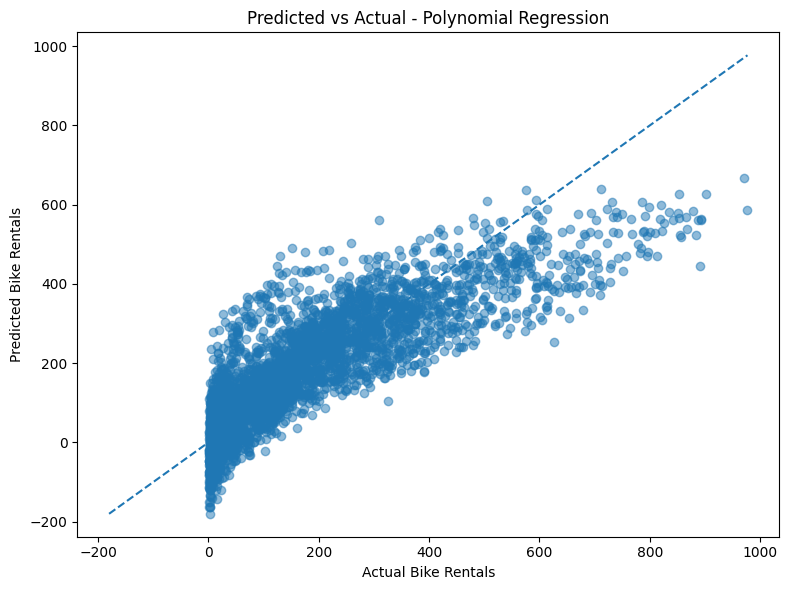

In [37]:
# Predicted vs Actual plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

# Reference line: perfect predictions
min_value = min(y_test.min(), final_predictions.min())
max_value = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title(f"Predicted vs Actual - {best_model_name}")

plt.tight_layout()
plt.show()

In [38]:
# Calculate residuals

residuals = y_test - final_predictions

print("Residuals calculated successfully.")

Residuals calculated successfully.


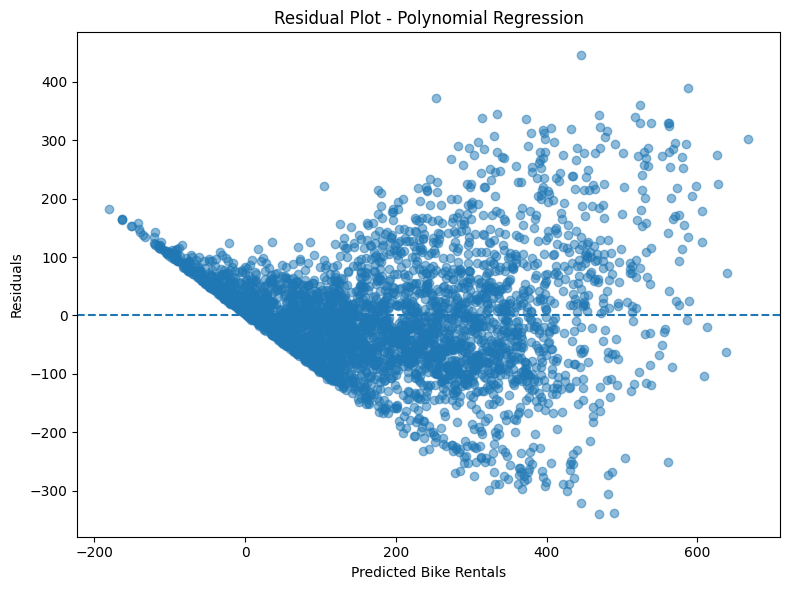

In [39]:
# Residual plot

plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Bike Rentals")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")

plt.tight_layout()
plt.show()

In [40]:
# Save the first 5 model results
reg15_final_results = tuned_results_df.copy()
reg15_final_cv = cv_results_df.copy()

# Save them as CSV files
reg15_final_results.to_csv("reg15_final_results.csv", index=False)
reg15_final_cv.to_csv("reg15_final_cv.csv", index=False)

print("First 5 model results saved successfully.")

First 5 model results saved successfully.


---

### 12.6 Decision Tree Regressor

Decision Tree Regression models nonlinear relationships by recursively
splitting the feature space into smaller regions.

In [41]:
decision_tree_model = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

decision_tree_model, dt_predictions, dt_r2, dt_rmse, dt_mae = (
    evaluate_regression_model(
        decision_tree_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Decision Tree Regressor")
print("R²  :", dt_r2)
print("RMSE:", dt_rmse)
print("MAE :", dt_mae)

Decision Tree Regressor
R²  : 0.862331645087864
RMSE: 66.02518524249743
MAE : 39.48849252013809


### 12.7 Random Forest Regressor

Random Forest is an ensemble of multiple decision trees. It combines their
predictions to improve generalisation and capture nonlinear relationships.

In [42]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model, rf_predictions, rf_r2, rf_rmse, rf_mae = (
    evaluate_regression_model(
        random_forest_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Random Forest Regressor")
print("R²  :", rf_r2)
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)

Random Forest Regressor
R²  : 0.9291658005314706
RMSE: 47.36025826428324
MAE : 29.662206559263517


### 12.8 Gradient Boosting Regressor

Gradient Boosting builds an ensemble of weak prediction models sequentially,
where each new model attempts to reduce the errors made by the previous
models.

In [43]:
gradient_boosting_model = GradientBoostingRegressor(
    random_state=RANDOM_STATE
)

gradient_boosting_model, gb_predictions, gb_r2, gb_rmse, gb_mae = (
    evaluate_regression_model(
        gradient_boosting_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Gradient Boosting Regressor")
print("R²  :", gb_r2)
print("RMSE:", gb_rmse)
print("MAE :", gb_mae)

Gradient Boosting Regressor
R²  : 0.7953655892562478
RMSE: 80.49740859055248
MAE : 58.255041837248584


### 12.9 Support Vector Regressor (SVR)

Support Vector Regression attempts to fit a function within a specified
error margin. Since the features have already been scaled during
preprocessing, SVR can operate effectively on the transformed feature space.

In [44]:
svr_model = SVR(
    kernel="rbf",
    C=10
)

svr_model, svr_predictions, svr_r2, svr_rmse, svr_mae = (
    evaluate_regression_model(
        svr_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Support Vector Regressor")
print("R²  :", svr_r2)
print("RMSE:", svr_rmse)
print("MAE :", svr_mae)

Support Vector Regressor
R²  : 0.7134051452894515
RMSE: 95.2635500142713
MAE : 58.1894390025072


### 12.10 K-Nearest Neighbors Regressor

KNN Regression predicts the target value using the target values of nearby
training observations. Feature scaling is important because KNN relies on
distance calculations.

In [45]:
knn_model = KNeighborsRegressor(
    n_neighbors=5,
    n_jobs=-1
)

knn_model, knn_predictions, knn_r2, knn_rmse, knn_mae = (
    evaluate_regression_model(
        knn_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("K-Nearest Neighbors Regressor")
print("R²  :", knn_r2)
print("RMSE:", knn_rmse)
print("MAE :", knn_mae)

K-Nearest Neighbors Regressor
R²  : 0.5665938601561613
RMSE: 117.14940756956919
MAE : 82.61121979286536


### 12.11 Regression Model Comparison

The performance of all ten regression algorithms is consolidated into a
single comparison table. The models are ranked according to their R² score.

In [46]:
# Store results from all ten regression models

results = [
    ["Decision Tree", dt_r2, dt_rmse, dt_mae],
    ["Random Forest", rf_r2, rf_rmse, rf_mae],
    ["Gradient Boosting", gb_r2, gb_rmse, gb_mae],
    ["SVR", svr_r2, svr_rmse, svr_mae],
    ["KNN", knn_r2, knn_rmse, knn_mae]
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "R²", "RMSE", "MAE"]
)

# Rank models by R²
results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

# Display the comparison table
results_df

,Model,R²,RMSE,MAE
0,Random Forest,0.929166,47.360258,29.662207
1,Decision Tree,0.862332,66.025185,39.488493
2,Gradient Boosting,0.795366,80.497409,58.255042
3,SVR,0.713405,95.263550,58.189439
4,KNN,0.566594,117.149408,82.611220


## 13. Hyperparameter Tuning

The baseline models were trained using their initial parameter settings.
In this section, hyperparameter tuning is performed on Random Forest and
Gradient Boosting using GridSearchCV.

GridSearchCV evaluates different combinations of hyperparameters using
cross-validation on the training data and selects the combination that
provides the best R² score.

The test set remains untouched during tuning and is used only for the final
evaluation of the tuned models.

### Decision Tree hyperparameter tuning

In [47]:
# Decision Tree hyperparameter tuning

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=RANDOM_STATE
        ))
    ]
)

dt_param_grid = {
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print("Best CV R²:", dt_grid.best_score_)

Best Decision Tree Parameters: {'model__max_depth': None, 'model__min_samples_split': 10}
Best CV R²: 0.8373269414723934


### 13.6 Random Forest Regression Hyper Tuning

In [48]:
# Random Forest hyperparameter tuning

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 15, 25],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best CV R²:", rf_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV R²: 0.9112279769105154


### 13.7 Gradient Boosting Regression Hyper Tuning

In [49]:
# Gradient Boosting hyperparameter tuning

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ]
)

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
print("Best CV R²:", gb_grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Gradient Boosting Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV R²: 0.858625968114738


### 13.8 SVR Hyper Tuning

In [50]:
# SVR hyperparameter tuning

svr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR())
    ]
)

svr_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"]
}

svr_grid = GridSearchCV(
    svr_pipeline,
    svr_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

svr_grid.fit(X_train, y_train)

print("Best SVR Parameters:", svr_grid.best_params_)
print("Best CV R²:", svr_grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best SVR Parameters: {'model__C': 100, 'model__kernel': 'rbf'}
Best CV R²: 0.9087227021291943


### 13.9 KNN Regression Hyper Tuning

In [51]:
# KNN hyperparameter tuning

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(
            n_jobs=-1
        ))
    ]
)

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best KNN Parameters:", knn_grid.best_params_)
print("Best CV R²:", knn_grid.best_score_)

Best KNN Parameters: {'model__n_neighbors': 15}
Best CV R²: 0.5365262956509965


## 14. Tuned Model Evaluation

The tuned models are evaluated on the same held-out test set used for
the baseline models. This allows a fair comparison between the baseline
and tuned versions of each regression algorithm.

The evaluation metrics used are R², RMSE, and MAE.

In [52]:
# Store tuned models and their predictions

tuned_models = {
    "Decision Tree": dt_grid,
    "Random Forest": rf_grid,
    "Gradient Boosting": gb_grid,
    "SVR": svr_grid,
    "KNN": knn_grid
}

tuned_results = []

for name, model in tuned_models.items():

    predictions = model.predict(X_test)

    
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    tuned_results.append([
        name,
        r2,
        rmse,
        mae
    ])

tuned_results_df = pd.DataFrame(
    tuned_results,
    columns=["Model", "R²", "RMSE", "MAE"]
)

tuned_results_df = tuned_results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

tuned_results_df

,Model,R²,RMSE,MAE
0,Random Forest,0.930251,46.995915,29.473037
1,SVR,0.925458,48.583930,29.831573
2,Decision Tree,0.875984,62.665893,37.601490
3,Gradient Boosting,0.868160,64.612490,45.864673
4,KNN,0.567553,117.019745,86.108669


In [53]:
# Create baseline results table with consistent model names

baseline_results_df = results_df.copy()

baseline_results_df = baseline_results_df.rename(
    columns={
        "R²": "Baseline R²",
        "RMSE": "Baseline RMSE",
        "MAE": "Baseline MAE"
    }
)

tuned_comparison_df = tuned_results_df.rename(
    columns={
        "R²": "Tuned R²",
        "RMSE": "Tuned RMSE",
        "MAE": "Tuned MAE"
    }
)

baseline_vs_tuned = baseline_results_df.merge(
    tuned_comparison_df,
    on="Model",
    how="left"
)

baseline_vs_tuned["R² Improvement"] = (
    baseline_vs_tuned["Tuned R²"]
    - baseline_vs_tuned["Baseline R²"]
)

baseline_vs_tuned["RMSE Improvement"] = (
    baseline_vs_tuned["Baseline RMSE"]
    - baseline_vs_tuned["Tuned RMSE"]
)

baseline_vs_tuned["MAE Improvement"] = (
    baseline_vs_tuned["Baseline MAE"]
    - baseline_vs_tuned["Tuned MAE"]
)

baseline_vs_tuned.sort_values(
    by="Tuned R²",
    ascending=False
).reset_index(drop=True)

,Model,Baseline R²,Baseline RMSE,Baseline MAE,Tuned R²,Tuned RMSE,Tuned MAE,R² Improvement,RMSE Improvement,MAE Improvement
0,Random Forest,0.929166,47.360258,29.662207,0.930251,46.995915,29.473037,0.001086,0.364344,0.189170
1,SVR,0.713405,95.263550,58.189439,0.925458,48.583930,29.831573,0.212053,46.679620,28.357866
2,Decision Tree,0.862332,66.025185,39.488493,0.875984,62.665893,37.601490,0.013652,3.359292,1.887003
3,Gradient Boosting,0.795366,80.497409,58.255042,0.868160,64.612490,45.864673,0.072794,15.884918,12.390369
4,KNN,0.566594,117.149408,82.611220,0.567553,117.019745,86.108669,0.000959,0.129662,-3.497449


## 15. 5-Fold Cross-Validation

Five-fold cross-validation is performed on the training data for all
regression models. The training data is divided into five folds, with
each fold being used once as the validation set while the remaining
four folds are used for training.

The mean and standard deviation of the R² scores are reported to
compare the consistency of model performance across different folds.

The held-out test set is not used during cross-validation.

In [54]:
from sklearn.model_selection import KFold, cross_val_score

# Five-fold cross-validation setup

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-Fold Cross-Validation configured successfully.")

5-Fold Cross-Validation configured successfully.


In [55]:
# Add Linear Regression because it does not have hyperparameters to tune

all_models_for_cv = {
    "Decision Tree": dt_grid,
    "Random Forest": rf_grid,
    "Gradient Boosting": gb_grid,
    "SVR": svr_grid,
    "KNN": knn_grid
}

In [56]:
# Perform 5-fold cross-validation for all models

cv_results = []

for model_name, model in all_models_for_cv.items():

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append([
        model_name,
        cv_scores.mean(),
        cv_scores.std()
    ])

    print(f"{model_name}")
    print("Fold R² scores:", cv_scores)
    print("Mean R²:", cv_scores.mean())
    print("Standard Deviation:", cv_scores.std())
    print("-" * 50)

Decision Tree
Fold R² scores: [0.86014024 0.8543453  0.8609322  0.86730382 0.85695374]
Mean R²: 0.8599350602920154
Standard Deviation: 0.004369638356411133
--------------------------------------------------
Random Forest
Fold R² scores: [0.92007461 0.91332009 0.92002689 0.91878312 0.91796956]
Mean R²: 0.9180348539659325
Standard Deviation: 0.00248684402466854
--------------------------------------------------
Gradient Boosting
Fold R² scores: [0.86686185 0.85024023 0.85870076 0.8643506  0.856161  ]
Mean R²: 0.8592628867899565
Standard Deviation: 0.005915657615596383
--------------------------------------------------
SVR
Fold R² scores: [0.92238618 0.91421264 0.91602542 0.91990138 0.91761597]
Mean R²: 0.9180283186434623
Standard Deviation: 0.0028719445781113027
--------------------------------------------------
KNN
Fold R² scores: [0.5629041  0.5475468  0.56211014 0.54754425 0.52233993]
Mean R²: 0.5484890439934975
Standard Deviation: 0.014689344856071361
--------------------------------

In [57]:
cv_results_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean 5-Fold CV R²",
        "CV R² Std"
    ]
)

cv_results_df = cv_results_df.sort_values(
    by="Mean 5-Fold CV R²",
    ascending=False
).reset_index(drop=True)

cv_results_df

,Model,Mean 5-Fold CV R²,CV R² Std
0,Random Forest,0.918035,0.002487
1,SVR,0.918028,0.002872
2,Decision Tree,0.859935,0.004370
3,Gradient Boosting,0.859263,0.005916
4,KNN,0.548489,0.014689


## 16. Regression Visualisations

The visualisations below are used to assess the prediction performance
of the selected regression model. Predicted values are compared with
actual target values, and residuals are examined to identify systematic
prediction errors.

In [58]:
# Select the model with the highest mean 5-fold CV R²

best_model_name = cv_results_df.iloc[0]["Model"]

print("Selected model:", best_model_name)

Selected model: Random Forest


In [59]:
# Get predictions from the selected model

if best_model_name == "Linear Regression":
    final_model = linear_model
else:
    final_model = all_models_for_cv[best_model_name]

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

print("Predictions generated successfully.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Predictions generated successfully.


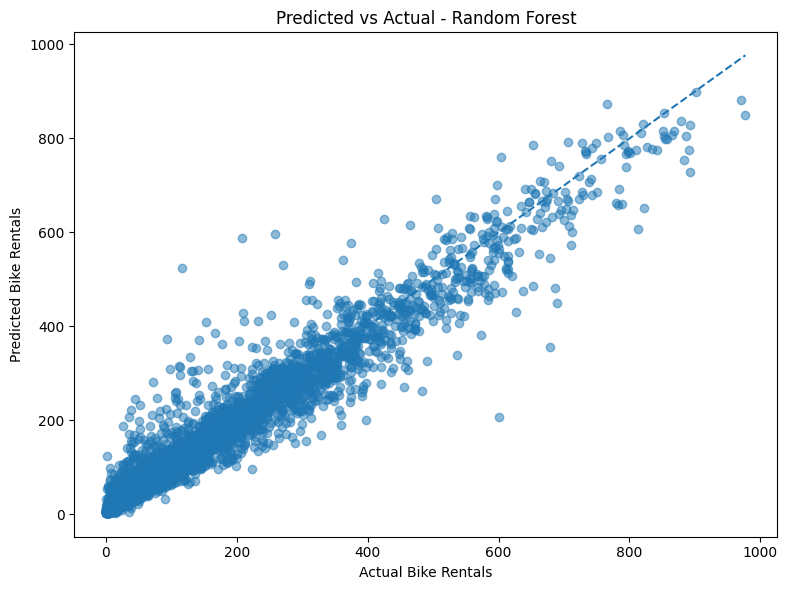

In [60]:
# Predicted vs Actual plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

# Reference line: perfect predictions
min_value = min(y_test.min(), final_predictions.min())
max_value = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title(f"Predicted vs Actual - {best_model_name}")

plt.tight_layout()
plt.show()

In [61]:
# Calculate residuals

residuals = y_test - final_predictions

print("Residuals calculated successfully.")

Residuals calculated successfully.


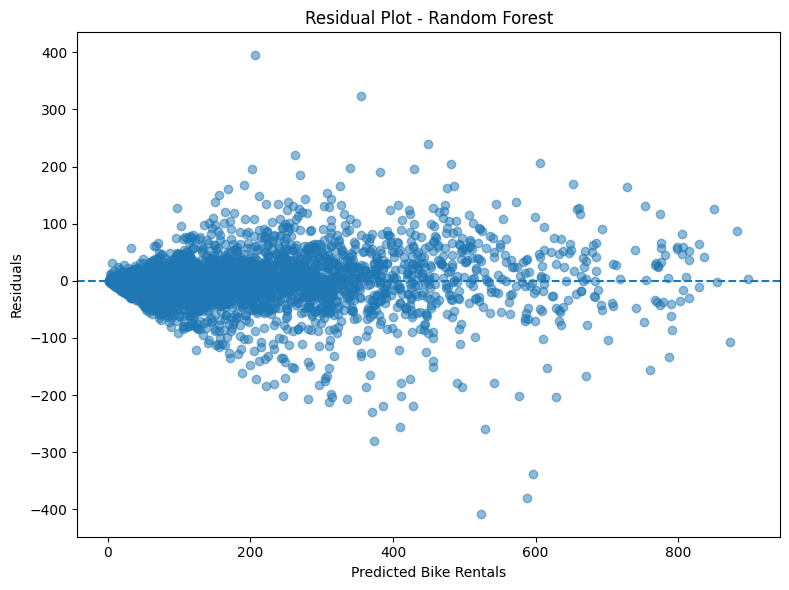

In [62]:
# Residual plot

plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Bike Rentals")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")

plt.tight_layout()
plt.show()

## 17. Feature Importance

Feature importance is examined using the tuned Random Forest model.
It shows the relative contribution of the input features to the model's
predictions.

The importance values are extracted from the trained Random Forest and
the corresponding feature names are obtained from the preprocessing
pipeline.

In [63]:
# Extract the fitted preprocessing pipeline and Random Forest model

rf_fitted_preprocessor = rf_grid.best_estimator_.named_steps["preprocessor"]
rf_fitted_model = rf_grid.best_estimator_.named_steps["model"]

# Get feature names after preprocessing
feature_names = rf_fitted_preprocessor.get_feature_names_out()

# Get feature importance values
feature_importances = rf_fitted_model.feature_importances_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(20)

,Feature,Importance
0,num__atemp,0.153959
1,cat__hr_17,0.093507
2,cat__hr_18,0.073846
3,num__hum,0.073490
4,cat__hr_8,0.060423
5,num__temp,0.054375
6,cat__workingday_0,0.046316
7,cat__workingday_1,0.045859
8,cat__yr_1,0.040880
9,cat__yr_0,0.039997


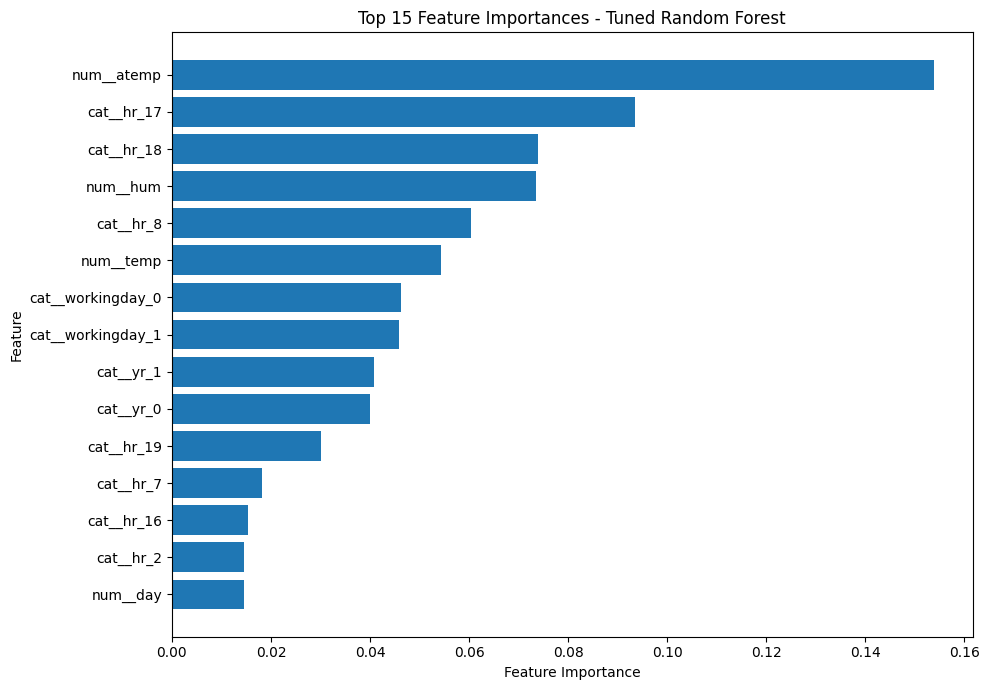

In [64]:
# Plot the top 15 most important features

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Tuned Random Forest")

plt.tight_layout()
plt.show()

In [65]:
# Verify that feature importance values sum to approximately 1

print(
    "Total feature importance:",
    feature_importance_df["Importance"].sum()
)

Total feature importance: 1.0000000000000002


## 18. Final Results and Comparison

The final comparison combines the performance of all ten regression
algorithms after model training and hyperparameter tuning.

R², RMSE, and MAE are reported on the same held-out test set.
The five-fold cross-validation R² results are also included to assess
the consistency of model performance.

In [ ]:


# Linear-family regression results
linear_results = pd.read_csv("first610_final_results.csv")
linear_cv = pd.read_csv("first610_final_cv.csv")

# Nonlinear / distance-based regression results
nonlinear_results = pd.read_csv("reg15_final_results.csv")
nonlinear_cv = pd.read_csv("reg15_final_cv.csv")

print("All four result files loaded successfully.")

All four result files loaded successfully.


In [ ]:

# Linear-family regression results
linear_results = pd.read_csv("first610_final_results.csv")
linear_cv = pd.read_csv("first610_final_cv.csv")

# Nonlinear / distance-based regression results
nonlinear_results = pd.read_csv("reg15_final_results.csv")
nonlinear_cv = pd.read_csv("reg15_final_cv.csv")

print("All four result files loaded successfully.")

All four result files loaded successfully.


In [71]:
# Combine 5-fold CV results for all 10 models

all10_cv = pd.concat(
    [linear_cv, nonlinear_cv],
    ignore_index=True
)

# Sort by mean CV R²
all10_cv = all10_cv.sort_values(
    by="Mean 5-Fold CV R²",
    ascending=False
).reset_index(drop=True)

all10_cv

,Model,Mean 5-Fold CV R²,CV R² Std
0,Random Forest,0.918035,0.002487
1,SVR,0.918028,0.002872
2,Decision Tree,0.859935,0.004370
3,Gradient Boosting,0.859263,0.005916
4,Polynomial Regression,0.700244,0.013617
5,ElasticNet Regression,0.683313,0.014477
6,Ridge Regression,0.683312,0.014483
7,Lasso Regression,0.683294,0.014540
8,KNN,0.548489,0.014689
9,Linear Regression,0.387050,0.012009


In [ ]:


test_results = pd.concat(
    [linear_results, nonlinear_results],
    ignore_index=True
)

# Sort by R² from highest to lowest
test_results = test_results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

# Add ranking
test_results.insert(
    0,
    "Rank",
    range(1, len(test_results) + 1)
)

# Display rounded results
test_results_display = test_results.copy()

for column in ["R²", "RMSE", "MAE"]:
    if column in test_results_display.columns:
        test_results_display[column] = test_results_display[column].round(4)

display(test_results_display)

,Rank,Model,R2,RMSE,MAE
0,1,Random Forest,0.930251,46.9959,29.4730
1,2,SVR,0.925458,48.5839,29.8316
2,3,Decision Tree,0.875984,62.6659,37.6015
3,4,Gradient Boosting,0.868160,64.6125,45.8647
4,5,Polynomial Regression,0.699208,97.5946,72.4143
5,6,Lasso Regression,0.681688,100.3966,74.0587
6,7,ElasticNet Regression,0.681579,100.4138,74.0847
7,8,Ridge Regression,0.681555,100.4176,74.0871
8,9,Linear Regression,0.681421,100.4387,74.0996
9,10,KNN,0.567553,117.0197,86.1087


In [73]:
# Identify the best model according to each test metric

best_r2_model = test_results.loc[
    test_results["R2"].idxmax(), "Model"
]

best_rmse_model = test_results.loc[
    test_results["RMSE"].idxmin(), "Model"
]

best_mae_model = test_results.loc[
    test_results["MAE"].idxmin(), "Model"
]

print("Highest Test R²   :", best_r2_model)
print("Lowest Test RMSE  :", best_rmse_model)
print("Lowest Test MAE   :", best_mae_model)

Highest Test R²   : Random Forest
Lowest Test RMSE  : Random Forest
Lowest Test MAE   : Random Forest


In [74]:
print("Linear results columns:")
print([repr(col) for col in linear_results.columns])

print("\nNonlinear results columns:")
print([repr(col) for col in nonlinear_results.columns])

Linear results columns:
["'Model'", "'R2'", "'RMSE'", "'MAE'"]

Nonlinear results columns:
["'Model'", "'R2'", "'RMSE'", "'MAE'"]


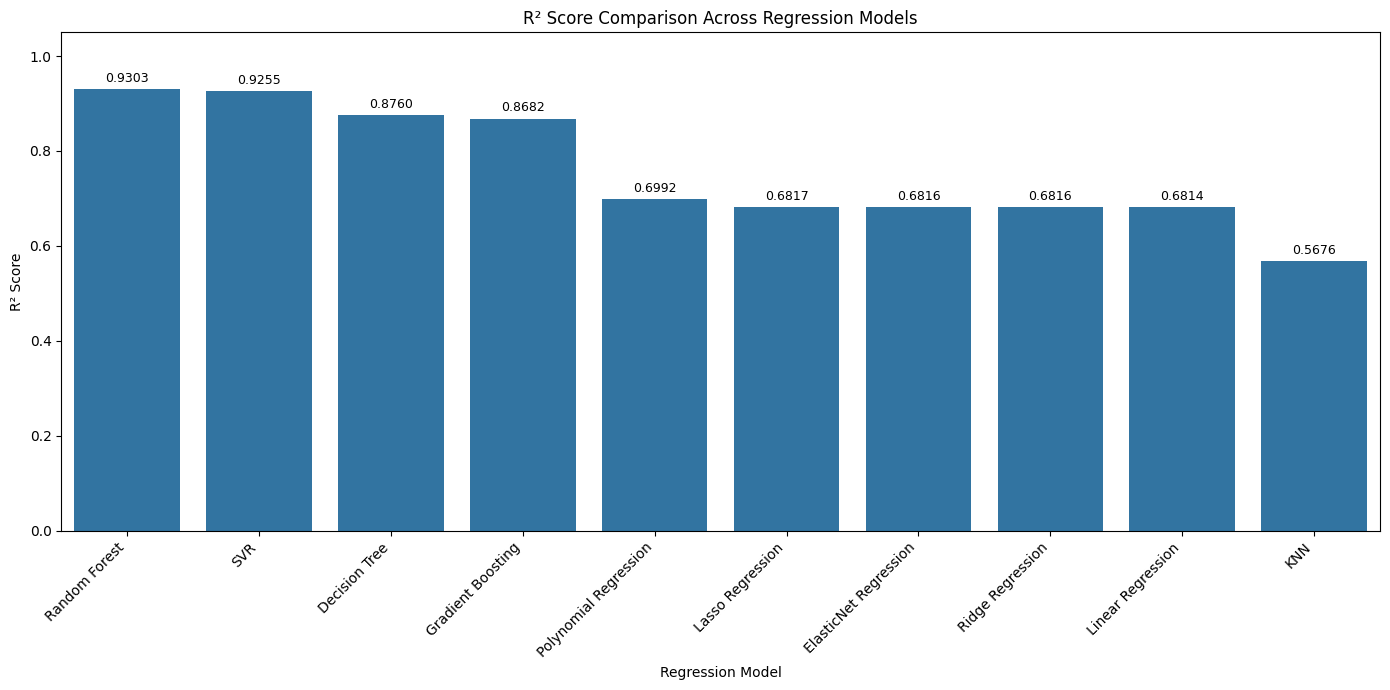

In [ ]:

# R² Score Comparison with Values

plot_data = test_results.sort_values(
    by="R2",
    ascending=False
).copy()

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=plot_data,
    x="Model",
    y="R2"
)

# Add R² values on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
        fontsize=9
    )

plt.title("R² Score Comparison Across Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

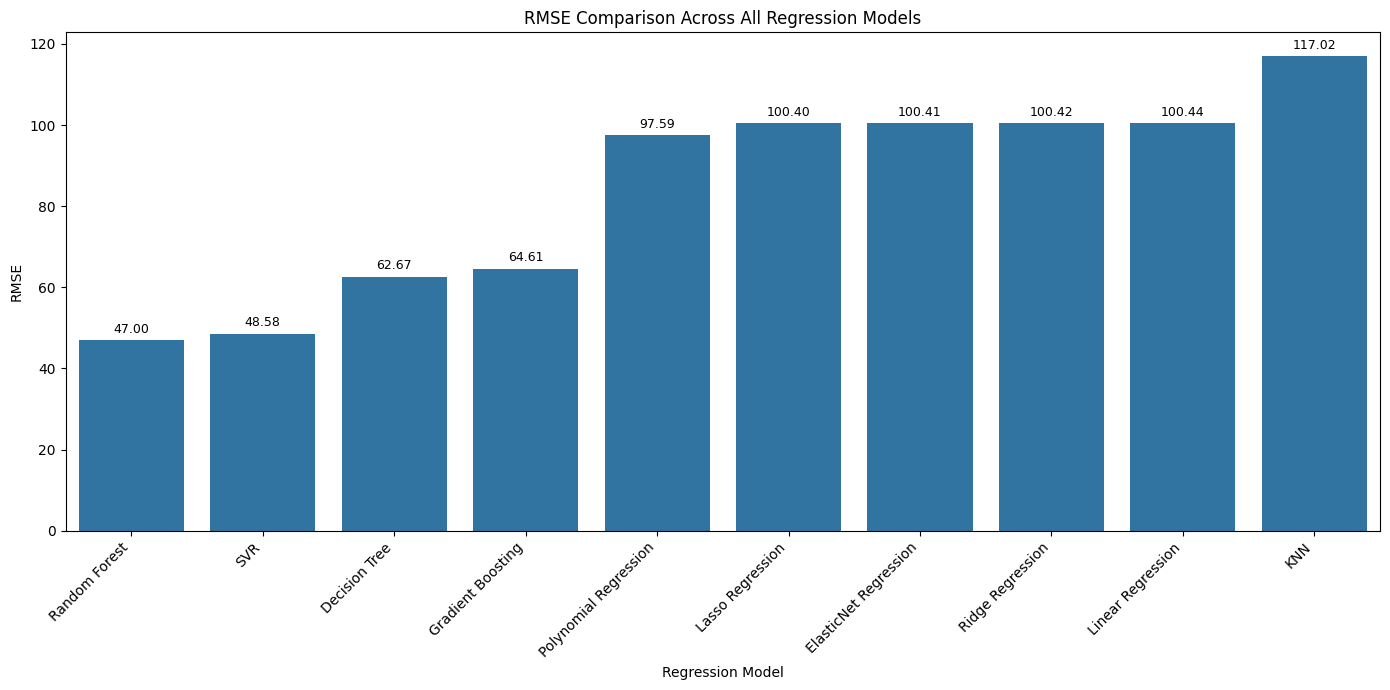

In [ ]:

# RMSE Comparison with Values


plot_data = test_results.sort_values(
    by="RMSE",
    ascending=True
).copy()

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=plot_data,
    x="Model",
    y="RMSE"
)

# Add RMSE values on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.title("RMSE Comparison Across All Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("RMSE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## Final Observations

The final results are examined using the test-set performance and the
five-fold cross-validation results.

The following observations are based directly on the experimental
results obtained in this project.